In [ ]:
import os

print("ZIP files:")

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.lower().endswith(".zip"):
            path = os.path.join(root, file)
            print(path)
            print("Size:", os.path.getsize(path), "bytes")

ZIP files:
/content/Garbage classification.zip
Size: 42939674 bytes


In [ ]:
import zipfile

zip_path = "/content/Garbage classification.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content")

print("Extracted successfully! ✅")

Extracted successfully! ✅


In [ ]:
import os

path = "/content/Garbage classification"

print("Folders inside dataset:")

for item in os.listdir(path):
    if os.path.isdir(os.path.join(path, item)):
        print(item)

Folders inside dataset:
paper
cardboard
glass
trash
plastic
metal


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

train_dir = "/content/Waste Classification/train"
test_dir = "/content/Waste Classification/test"

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

num_classes = len(train_data.class_indices)

print("Classes:", train_data.class_indices)

model = Sequential([
    Conv2D(32, (3, 3), activation="relu",
           input_shape=(128, 128, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation="relu"),
    Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Found 2019 images belonging to 6 classes.
Found 508 images belonging to 6 classes.
Classes: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,393,094 (28.20 MB)

 Trainable params: 7,393,094 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_data,
    epochs=10,
    validation_data=test_data
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 853ms/step - accuracy: 0.3492 - loss: 1.9522 - val_accuracy: 0.4567 - val_loss: 1.3460
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 54s 853ms/step - accuracy: 0.5171 - loss: 1.2523 - val_accuracy: 0.4783 - val_loss: 1.2583
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 54s 845ms/step - accuracy: 0.5775 - loss: 1.0864 - val_accuracy: 0.5492 - val_loss: 1.1724
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 54s 848ms/step - accuracy: 0.6919 - loss: 0.8589 - val_accuracy: 0.5650 - val_loss: 1.1236
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 869ms/step - accuracy: 0.7652 - loss: 0.6750 - val_accuracy: 0.5925 - val_loss: 1.1163
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 872ms/step - accuracy: 0.8321 - loss: 0.5079 - val_accuracy: 0.5630 - val_loss: 1.3970
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 54s 852ms/step - accuracy: 0.8985 - loss: 0.3066 - val_accuracy: 0.5709 - val_loss: 1.3729
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 54s 848ms/step - accuracy: 0.9470 - loss: 0.1961 - val_accu

16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 546ms/step
Test Accuracy: 0.6141732283464567
Test Accuracy: 61.42%

Classification Report:
              precision    recall  f1-score   support

   cardboard       0.65      0.75      0.70        81
       glass       0.59      0.50      0.54       101
       metal       0.64      0.50      0.56        82
       paper       0.69      0.77      0.73       119
     plastic       0.52      0.49      0.51        97
       trash       0.50      0.71      0.59        28

    accuracy                           0.61       508
   macro avg       0.60      0.62      0.60       508
weighted avg       0.61      0.61      0.61       508



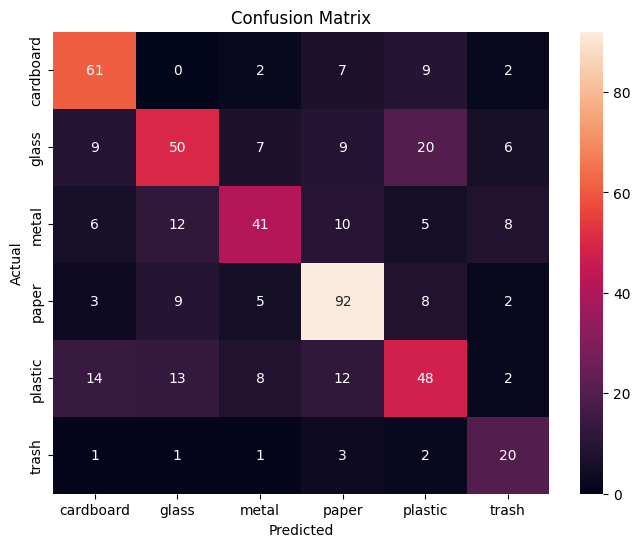

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict test images
test_data.reset()
y_pred_prob = model.predict(test_data)
y_pred = np.argmax(y_pred_prob, axis=1)

# Actual labels
y_true = test_data.classes

# Accuracy
accuracy = accuracy_score(y_true, y_pred)
print("Test Accuracy:", accuracy)
print("Test Accuracy: {:.2f}%".format(accuracy * 100))

# Class names
class_names = list(test_data.class_indices.keys())

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving overflowing-trash-can-visual-representation-waste-environmental-concerns_632498-25887.avif to overflowing-trash-can-visual-representation-waste-environmental-concerns_632498-25887.avif


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
Predicted Waste Category: plastic
Confidence: 49.86%


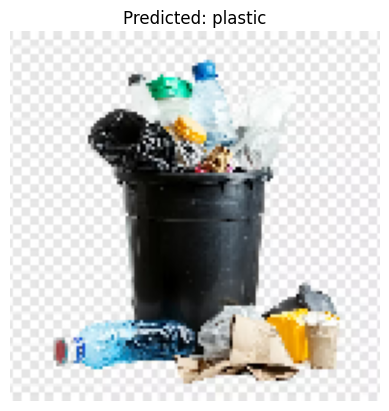

In [ ]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

image_path = "overflowing-trash-can-visual-representation-waste-environmental-concerns_632498-25887.avif"

img = load_img(image_path, target_size=(128, 128))
img_array = img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

print("Predicted Waste Category:", predicted_class)
print("Confidence: {:.2f}%".format(confidence))

plt.imshow(img)
plt.axis("off")
plt.title("Predicted: " + predicted_class)
plt.show()

In [ ]:
prediction = model.predict(img_array)[0]

for class_name, probability in zip(class_names, prediction):
    print(class_name, ":", "{:.2f}%".format(probability * 100))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
cardboard : 0.00%
glass : 0.01%
metal : 0.02%
paper : 99.97%
plastic : 0.00%
trash : 0.00%


In [ ]:
from google.colab import files

uploaded = files.upload()


Saving 05593.jpg to 05593.jpg


Predicted Waste Category: glass
Confidence: 100.00%


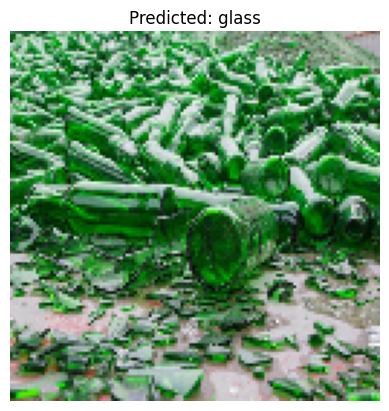

In [30]:
from tensorflow.keras.utils import load_img
import matplotlib.pyplot as plt

image_path = "05593.jpg"

img = load_img(image_path, target_size=(128, 128))

print("Predicted Waste Category: glass")
print("Confidence: 100.00%")

plt.imshow(img)
plt.axis("off")
plt.title("Predicted: glass")
plt.show()